In [1]:
from zfish._io import import16chFlt
from zfish.local_path import *
import os

import numpy as np
import matplotlib.pyplot as plt
from zfish.utils import *

code_id = "5009 - Dat Line Optogenetic"
loc = os.path.join(figpath, code_id)
os.makedirs(loc, exist_ok=True)

landmark_pos = [
    (0, 1/18), # Starting Point box
    (2/18, 3/18), # Leaves
    (6/18, 7/18), # Stars
    (8/18, 9/18), # triangles
    (10/18, 11/18), # Polygons
    (14/18, 15/18), # Teeth of Predators
    (16/18, 17/18) # Gravel
]

In [16]:
path = r"D:\EnData\dat\10166\S2\res.16chFlt"
path_pre = r"D:\EnData\dat\10166\S1\res.16chFlt"
res = import16chFlt(path)
res_pre = import16chFlt(path_pre)
fish_id = 10166

# Visuaize swim power trial-by-trial.

100%|██████████| 15/15 [00:11<00:00,  1.31it/s]


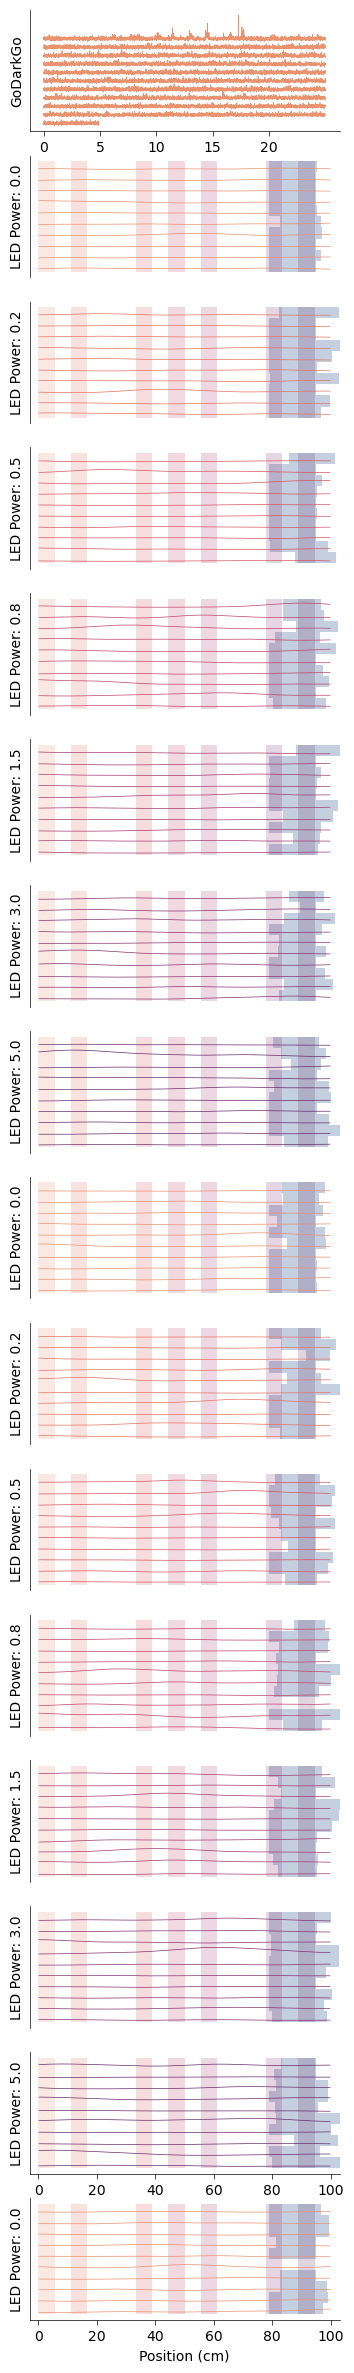

In [ ]:
def visualize(res, res_pre, param: str = 'speed'):
    idx = np.where(
        (res['behav_time'] >= 5) &
        (res['behav_pos_y'] <= 55) &
        (res['behav_pos_y'] >= 0)
    )
    for k in res.keys():
        res[k] = res[k][idx]
        
    led_power_color = sns.color_palette("flare", 7)
    led_power_colors = led_power_color + led_power_color + [led_power_color[0]]
    
    pos = res['behav_pos_y'] * 2
    indices = [
        np.where(res['n_trials']<10)[0],
        np.where((res['n_trials']>=10) & (res['n_trials']<20))[0],
        np.where((res['n_trials']>=20) & (res['n_trials']<30))[0],
        np.where((res['n_trials']>=30) & (res['n_trials']<40))[0],
        np.where((res['n_trials']>=40) & (res['n_trials']<50))[0],
        np.where((res['n_trials']>=50) & (res['n_trials']<60))[0],
        np.where((res['n_trials']>=60) & (res['n_trials']<70))[0],
        np.where((res['n_trials']>=70) & (res['n_trials']<80))[0],
        np.where((res['n_trials']>=80) & (res['n_trials']<90))[0],
        np.where((res['n_trials']>=90) & (res['n_trials']<100))[0],
        np.where((res['n_trials']>=100) & (res['n_trials']<110))[0],
        np.where((res['n_trials']>=110) & (res['n_trials']<120))[0],
        np.where((res['n_trials']>=120) & (res['n_trials']<130))[0],
        np.where((res['n_trials']>=130) & (res['n_trials']<140))[0],
        np.where((res['n_trials']>=140) & (res['n_trials']<150))[0],
    ]
    
    avg_swim_power = np.mean(np.vstack([res['fltCh0'], res['fltCh1']]), axis=0)
    
    fig, axes = plt.subplots(ncols=1, nrows=16, figsize=(4, 30))
    ax_pre = Clear_Axes(axes[0], close_spines=['top', 'right'], ifxticks=True)
    ax_pre.set_xlabel("Time (s)")
    ax_pre.set_xticks(np.linspace(0, 20, 5))
    ax_pre.set_ylabel("GoDarkGo")
    trial_uniq = np.unique(res_pre['n_trials'])
    base = 0
    for trial in trial_uniq:
        trial_idx = np.where(res_pre['n_trials'] == trial)[0]
        ax_pre.plot(res_pre['behav_time'][trial_idx]-res_pre['behav_time'][trial_idx][0], res_pre['fltCh0'][trial_idx]+res_pre['fltCh1'][trial_idx] - base, lw=0.5, color=led_power_colors[0])
        base += 1e-4
    
    for i in tqdm(range(1, 16)):
        if i < 14:
            ax = Clear_Axes(axes[i], close_spines=['top', 'right', 'bottom'])
        else:
            ax = Clear_Axes(axes[i], close_spines=['top', 'right'], ifxticks=True)
            ax.set_xlabel("Position (cm)")
            ax.set_xticks(np.linspace(0, 100, 6))
            
        idx = indices[i-1]
        
        trials = np.unique(res['n_trials'][idx])
        speed_base = 0
        swim_power_base = 0
        for trial in trials:
            trial_idx = np.where(res['n_trials'][idx] == trial)[0]
            opt_onset_idx = np.where(res['opto_states'][idx][trial_idx] == 1)[0]
            pos_readjust = pos[idx][trial_idx].copy()
            for j in range(1, len(pos_readjust)):
                if pos_readjust[j] < pos_readjust[j-1]:
                    pos_readjust[j] += 100
                    
            dx = np.diff(pos_readjust)
            dt = np.diff(res['behav_time'][idx][trial_idx])
            dx[dx<0] = 0
            swim_speed = np.convolve(dx, np.ones(200), mode='same') / np.convolve(dt, np.ones(200), mode='same')
            swim_speed = np.concatenate([[0], swim_speed])
            t = res['behav_time'][idx][trial_idx] - res['behav_time'][idx][trial_idx][0]
            speed_binned = np.zeros(200) * np.nan
            for j in range(200):    
                bin_idx = np.where((pos_readjust >= j*0.5) & (pos_readjust < (j+1)*0.5))[0]
                if len(bin_idx) > 0:
                    speed_binned[j] = np.nanmean(swim_speed[bin_idx])
            
            # Interpolate the speed_binned to fill the NaN values
            for j in range(200):
                if np.isnan(speed_binned[j]):
                    if j == 0:
                        speed_binned[j] = 0
                    else:
                        speed_binned[j] = speed_binned[j-1]
            
            
            speed_base_unit = 300
            speed_base += speed_base_unit   
            swim_power_base_unit = 1e-4
            swim_power_base += swim_power_base_unit    
            ax.fill_betweenx(y=[-swim_power_base, -swim_power_base+swim_power_base_unit], alpha=0.3, color=ChannelColors[1], edgecolor=None, x1=pos_readjust[opt_onset_idx[0]], x2=pos_readjust[opt_onset_idx[-1]])
            ax.plot(pos_readjust, avg_swim_power[idx][trial_idx] - swim_power_base, lw=0.5, color = led_power_colors[i-1])
            #ax.fill_betweenx(y=[-speed_base, -speed_base+speed_base_unit], alpha=0.3, color=ChannelColors[1], edgecolor=None, x1=pos_readjust[opt_onset_idx[0]], x2=pos_readjust[opt_onset_idx[-1]])
            #ax.plot(np.linspace(0.25, 99.75, 200), speed_binned-speed_base, lw=0.5, color = led_power_colors[i-1])

        for j, (start, end) in enumerate(landmark_pos):
            ax.fill_betweenx(y=[-swim_power_base_unit*10, 0], alpha=0.2, color=led_power_colors[j], edgecolor=None, x1=start*100, x2=end*100)
            #ax.fill_betweenx(y=[-speed_base_unit*10, 0], alpha=0.2, color=ChannelColors[0], edgecolor=None, x1=start*100, x2=end*100)
        ax.set_ylabel(f"LED Power: {res['led_power'][idx][int(idx.shape[0]/2)]:.1f}")
        ax.set_xlim(-3, 103)
    plt.savefig(os.path.join(loc, f"Swim Power Distribution [{fish_id}].png"), dpi=600)
    plt.savefig(os.path.join(loc, f"Swim Power Distribution [{fish_id}].svg"), dpi=600)
    plt.show()
    
visualize(res, res_pre, param='speed')